In [1]:
#Q1) Charger le dataset et afficher les 5 premières lignes, la taille et les colonnes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import zipfile
from tensorflow.keras.utils import get_file

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'


zip_path = get_file(
  fname="jena_climate_2009_2016.csv.zip",
  origin=url,
  extract=False
)
extract_dir = os.path.dirname(zip_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_dir)

csv_path = os.path. join(extract_dir, "jena_climate_2009_2016.csv")

df = pd.read_csv(csv_path)

print(df.head())
print("Shape du DataFrame :", df.shape)
print(df.columns.tolist())

             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

In [2]:
#Q2) Extraire uniquement T (degC) et expliquer le format (n,1)

data = df[['T (degC)']].values.reshape(-1,1)
print("Shape target :", data.shape)

Shape target : (420551, 1)


**Pourquoi le format (n, 1) ?**

 On transforme les données en format (n,1) au lieu de (n,) car MinMaxScaler attendent une matrice à deux dimensions (ligne = une observation, colonne = une variable) . Cela évite des erreurs de forme pendant la normalisation et pendant la reconstruction des séquences.

In [3]:
#Q3) Division temporelle Train / Validation / Test

n = len(data)

#70% train , 15% test , 15% val
train_size = int(0.7 * n)
val_size = int(0.15 * n)

train = data[:train_size]
val = data[train_size:train_size + val_size]
test = data[train_size + val_size:]

print(f'Train (70%) : {train.shape} ')
print(f'Valid (15%) : {val.shape} ')
print(f'Test  (15%) : {test.shape}')


Train (70%) : (294385, 1) 
Valid (15%) : (63082, 1) 
Test  (15%) : (63084, 1)


In [4]:
#Q4) Normalisation MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)
test_scaled = scaler.transform(test)


print("Train scaled min/max :", train_scaled.min(), train_scaled.max())

Train scaled min/max : 0.0 1.0


In [5]:
#Q5) Fonction create_sequences_multistep

def create_sequences_multistep(data, lookback, horizon):
    X, y = [], []

    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + horizon, 0])
    return np.array(X), np.array(y)


LOOKBACK = 72
HORIZON  = 10

In [6]:
#Q6) Création des séquences et affichage des dimensions

X_train, y_train = create_sequences_multistep(train_scaled, LOOKBACK, HORIZON)
X_val,   y_val   = create_sequences_multistep(val_scaled,   LOOKBACK, HORIZON)
X_test,  y_test  = create_sequences_multistep(test_scaled,  LOOKBACK, HORIZON)

print(f'X_train : {X_train.shape}  (sequences, lookback, features)')
print(f'y_train : {y_train.shape}  (sequences, horizon)')
print(f'X_val   : {X_val.shape}')
print(f'y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')


print("X_train[0] :", X_train[0])
print("y_train[0] :", y_train[0])


X_train : (294304, 72, 1)  (sequences, lookback, features)
y_train : (294304, 10)  (sequences, horizon)
X_val   : (63001, 72, 1)
y_val   : (63001, 10)
X_test  : (63003, 72, 1)
y_test  : (63003, 10)
X_train[0] : [[0.25462884]
 [0.24800408]
 [0.24630542]
 [0.24970273]
 [0.2503822 ]
 [0.25411925]
 [0.26142348]
 [0.26142348]
 [0.25649737]
 [0.24766435]
 [0.24205877]
 [0.24002038]
 [0.24052998]
 [0.24086971]
 [0.24375743]
 [0.24375743]
 [0.24307797]
 [0.24120944]
 [0.24069985]
 [0.23900119]
 [0.23900119]
 [0.24036012]
 [0.23815186]
 [0.23713267]
 [0.23407508]
 [0.22965857]
 [0.2294887 ]
 [0.23203669]
 [0.2299983 ]
 [0.22728045]
 [0.22660099]
 [0.22643112]
 [0.22269407]
 [0.22252421]
 [0.22931884]
 [0.22660099]
 [0.22795991]
 [0.23543401]
 [0.23951079]
 [0.23730253]
 [0.23067776]
 [0.23509428]
 [0.2429081 ]
 [0.24562596]
 [0.24817394]
 [0.2498726 ]
 [0.25276032]
 [0.25326992]
 [0.25259045]
 [0.25394938]
 [0.2558179 ]
 [0.25938509]
 [0.2622728 ]
 [0.26074401]
 [0.25989468]
 [0.26244267]
 [0.2

**Une ligne de y_train** :
Chaque ligne de y_train est un vecteur de horizon valeurs normalisées représentant les
températures futures aux instants t+1 a t+10, qui suivent directement la fenétre d'observation correspondante dans X_train .

**X_train[0]** contient les températures des instants passés.

**y_train[0]** contient les températures futures allant de t+1 à t+10.



In [7]:
#Q7) Construction des modéles

EPOCHS = 30
BATCH  = 128

# early_stop = EarlyStopping(
#     monitor='val_loss', patience=5,
#     restore_best_weights=True, verbose=1
# )

early_rnn = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
early_lstm = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
early_bilstm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

def build_simple_rnn():
    m = Sequential([
        SimpleRNN(64, input_shape=(LOOKBACK, 1)),
        Dense(HORIZON)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m


def build_lstm():
    m = Sequential([
        LSTM(64, input_shape=(LOOKBACK, 1)),
        Dense(HORIZON)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m


def build_bilstm():
    m = Sequential([
        Bidirectional(LSTM(64), input_shape=(LOOKBACK, 1)),
        Dense(HORIZON)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m


rnn_model    = build_simple_rnn()
lstm_model   = build_lstm()
bilstm_model = build_bilstm()

print('=== SimpleRNN ===')
rnn_model.summary()
print('\n=== LSTM ===')
lstm_model.summary()
print('\n=== BiLSTM ===')
bilstm_model.summary()

=== SimpleRNN ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,874 (19.04 KB)

 Trainable params: 4,874 (19.04 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,082 (137.04 KB)

 Trainable params: 35,082 (137.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#  Entratnement des modéles

rint('Entraînement SimpleRNN:')
history_rnn = rnn_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[early_rnn], verbose=1
)

Entraînement SimpleRNN:
Epoch 1/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0016 - mae: 0.0165 - val_loss: 2.7549e-04 - val_mae: 0.0111
Epoch 2/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 2.5572e-04 - mae: 0.0109 - val_loss: 2.2696e-04 - val_mae: 0.0100
Epoch 3/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 2.2101e-04 - mae: 0.0100 - val_loss: 2.0588e-04 - val_mae: 0.0094
Epoch 4/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 2.0415e-04 - mae: 0.0095 - val_loss: 1.9703e-04 - val_mae: 0.0091
Epoch 5/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.9339e-04 - mae: 0.0092 - val_loss: 1.8992e-04 - val_mae: 0.0089
Epoch 6/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.8846e-04 - mae: 0.0090 - val_loss: 1.8551e-04 - val_mae: 0.0088
Epoch 7/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.8510e-04 - mae: 0.0089 - val_loss: 1.7964e-04 - val_mae: 0.0085
Epoch 8/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 1.8201e-04 - m

In [9]:
print('\nEntraînement LSTM:')
history_lstm = lstm_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[early_lstm], verbose=1
)


Entraînement LSTM:
Epoch 1/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0018 - mae: 0.0190 - val_loss: 3.1046e-04 - val_mae: 0.0120
Epoch 2/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.7037e-04 - mae: 0.0111 - val_loss: 2.3961e-04 - val_mae: 0.0103
Epoch 3/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.2501e-04 - mae: 0.0100 - val_loss: 2.1782e-04 - val_mae: 0.0099
Epoch 4/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 2.0430e-04 - mae: 0.0095 - val_loss: 2.0444e-04 - val_mae: 0.0094
Epoch 5/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.9218e-04 - mae: 0.0092 - val_loss: 1.8520e-04 - val_mae: 0.0088
Epoch 6/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 1.8350e-04 - mae: 0.0089 - val_loss: 1.8790e-04 - val_mae: 0.0093
Epoch 7/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.7716e-04 - mae: 0.0087 - val_loss: 1.8369e-04 - val_mae: 0.0092
Epoch 8/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 1.7307e-04 - mae: 

In [10]:
print('\nEntraînement BiLSTM:')
history_bilstm = bilstm_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[early_bilstm], verbose=1
)


Entraînement BiLSTM:
Epoch 1/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - loss: 0.0016 - mae: 0.0188 - val_loss: 2.8295e-04 - val_mae: 0.0115
Epoch 2/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 2.5566e-04 - mae: 0.0110 - val_loss: 2.2521e-04 - val_mae: 0.0100
Epoch 3/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 2.1656e-04 - mae: 0.0099 - val_loss: 1.9936e-04 - val_mae: 0.0093
Epoch 4/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 1.9695e-04 - mae: 0.0094 - val_loss: 1.9770e-04 - val_mae: 0.0095
Epoch 5/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 1.8466e-04 - mae: 0.0090 - val_loss: 1.8304e-04 - val_mae: 0.0089
Epoch 6/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 1.7774e-04 - mae: 0.0088 - val_loss: 1.7625e-04 - val_mae: 0.0087
Epoch 7/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 1.7392e-04 - mae: 0.0086 - val_loss: 1.8020e-04 - val_mae: 0.0091
Epoch 8/30
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - loss: 1.7188e-

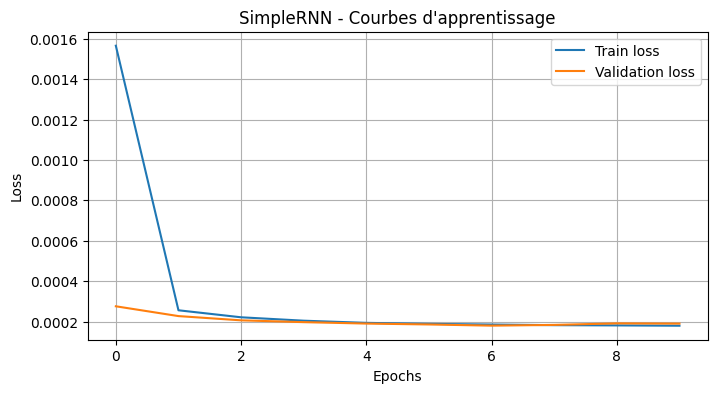

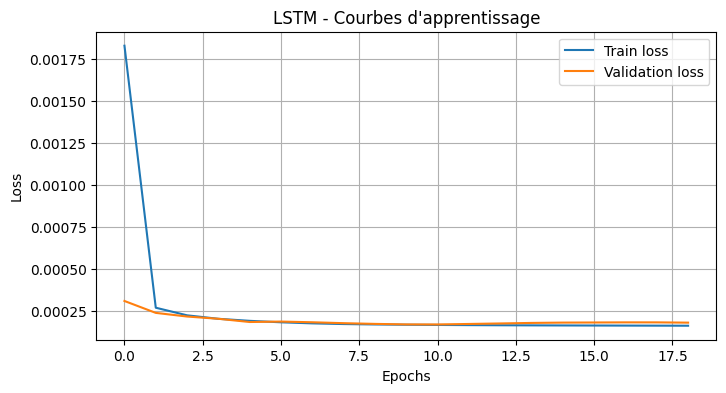

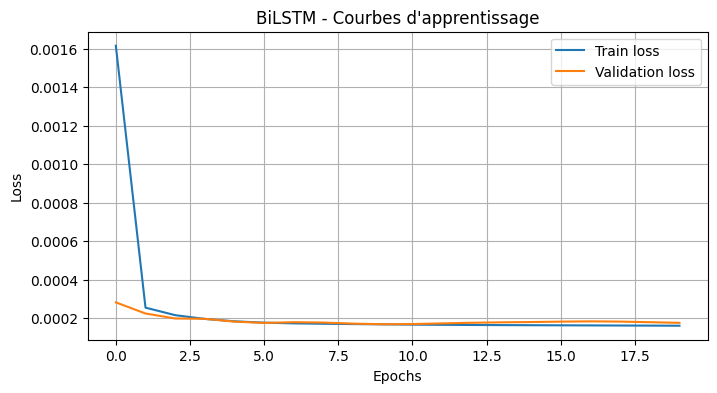

In [11]:
#Q8) Les courbes d’apprentissage

def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_rnn, "SimpleRNN - Courbes d'apprentissage")
plot_history(history_lstm, "LSTM - Courbes d'apprentissage")
plot_history(history_bilstm, "BiLSTM - Courbes d'apprentissage")

In [12]:
#Q9) Prédictions sur le test, inverse scaling et métriques par horizon

def evaluate_model(model, X_test, y_test, scaler, horizon, name):
    y_pred_norm = model.predict(X_test, verbose=0)
    y_pred = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).reshape(-1, horizon)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1, horizon)

    rows = []
    for h in range(horizon):
        mae  = mean_absolute_error(y_true[:, h], y_pred[:, h])
        rmse = np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h]))
        r2   = r2_score(y_true[:, h], y_pred[:, h])
        rows.append({'Horizon': f't+{h+1}', 'MAE (C)': round(mae, 4),
                     'RMSE (C)': round(rmse, 4), 'R2': round(r2, 4)})

    df_m = pd.DataFrame(rows)
    print(f'\n=== {name} ===')
    print(df_m.to_string(index=False))
    return y_pred, y_true, df_m


pred_rnn,true_test, met_rnn    = evaluate_model(rnn_model,    X_test, y_test, scaler, HORIZON, 'SimpleRNN')
pred_lstm,   _, met_lstm   = evaluate_model(lstm_model,   X_test, y_test, scaler, HORIZON, 'LSTM')
pred_bilstm, _, met_bilstm = evaluate_model(bilstm_model, X_test, y_test, scaler, HORIZON, 'LSTM Bidirectionnel')


=== SimpleRNN ===
Horizon  MAE (C)  RMSE (C)     R2
    t+1   0.1335    0.2021 0.9993
    t+2   0.2391    0.3573 0.9979
    t+3   0.3128    0.4632 0.9965
    t+4   0.3753    0.5559 0.9949
    t+5   0.4506    0.6549 0.9929
    t+6   0.5159    0.7442 0.9909
    t+7   0.5768    0.8218 0.9889
    t+8   0.6418    0.9105 0.9863
    t+9   0.7174    1.0011 0.9835
   t+10   0.7664    1.0748 0.9809

=== LSTM ===
Horizon  MAE (C)  RMSE (C)     R2
    t+1   0.1475    0.2131 0.9993
    t+2   0.2463    0.3598 0.9979
    t+3   0.3142    0.4616 0.9965
    t+4   0.3809    0.5535 0.9949
    t+5   0.4604    0.6555 0.9929
    t+6   0.5056    0.7207 0.9914
    t+7   0.5669    0.8023 0.9894
    t+8   0.6306    0.8841 0.9871
    t+9   0.6940    0.9656 0.9846
   t+10   0.7586    1.0475 0.9819

=== LSTM Bidirectionnel ===
Horizon  MAE (C)  RMSE (C)     R2
    t+1   0.1941    0.2503 0.9990
    t+2   0.2297    0.3448 0.9980
    t+3   0.3033    0.4500 0.9967
    t+4   0.3768    0.5499 0.9950
    t+5   0.4361    

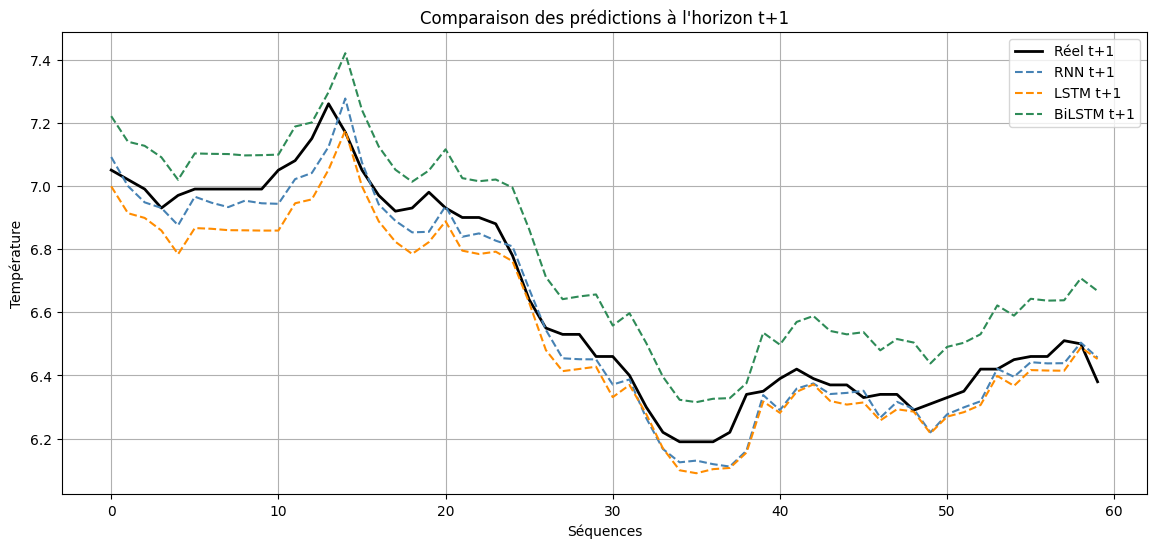

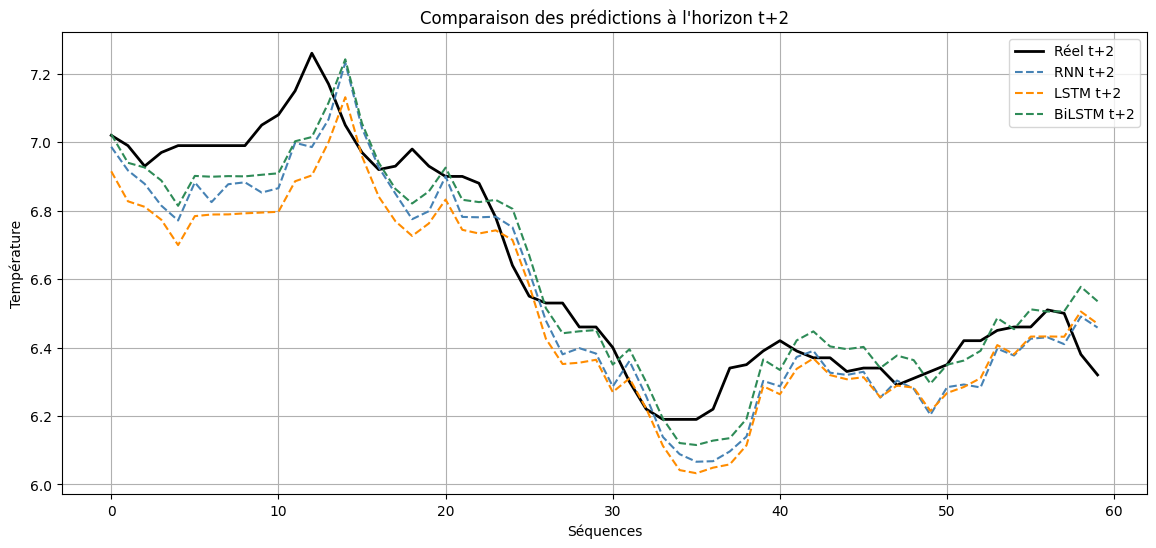

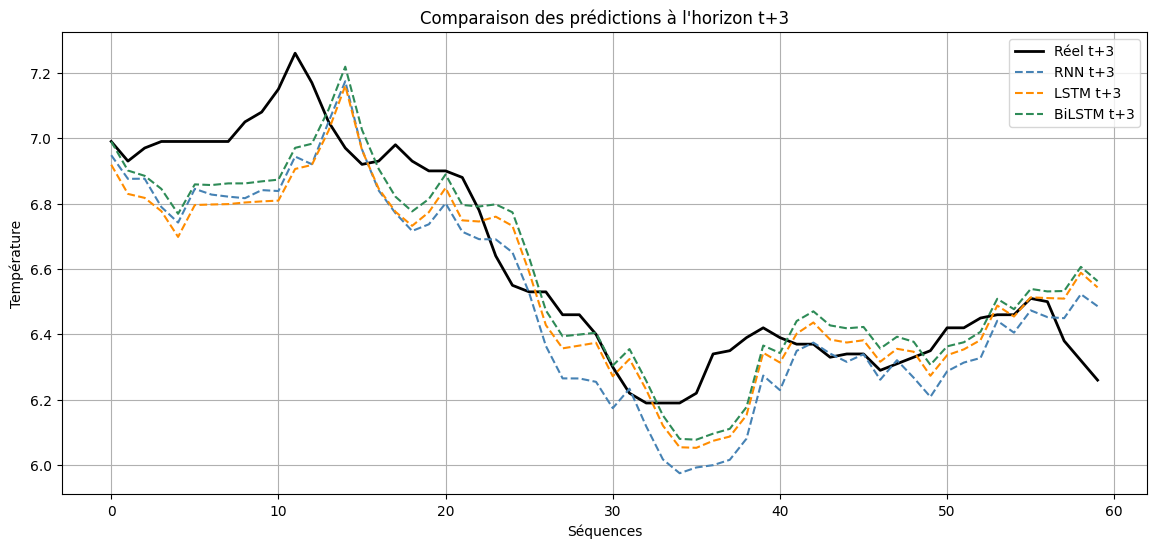

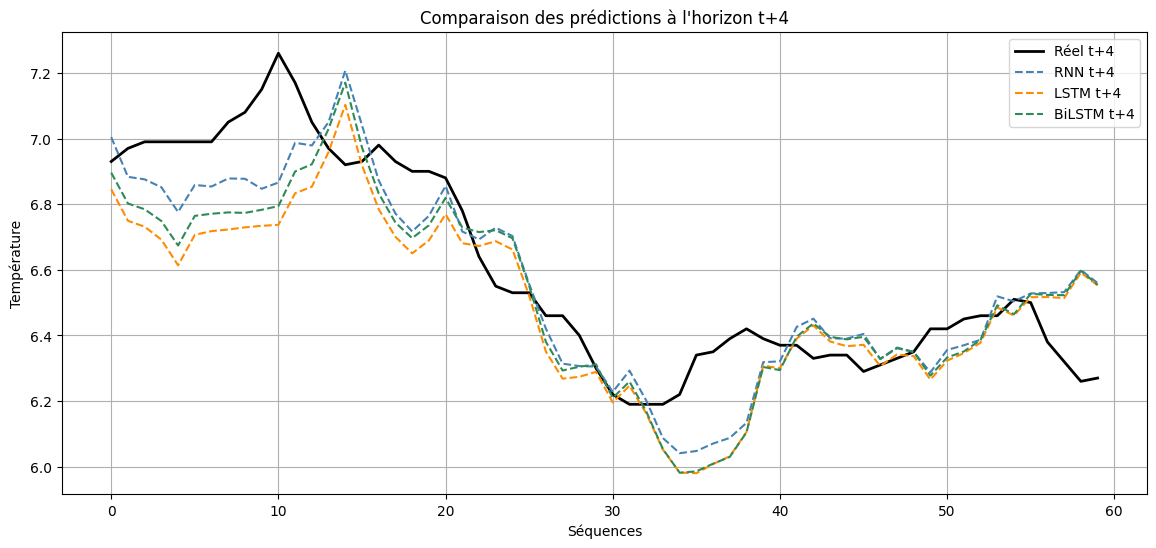

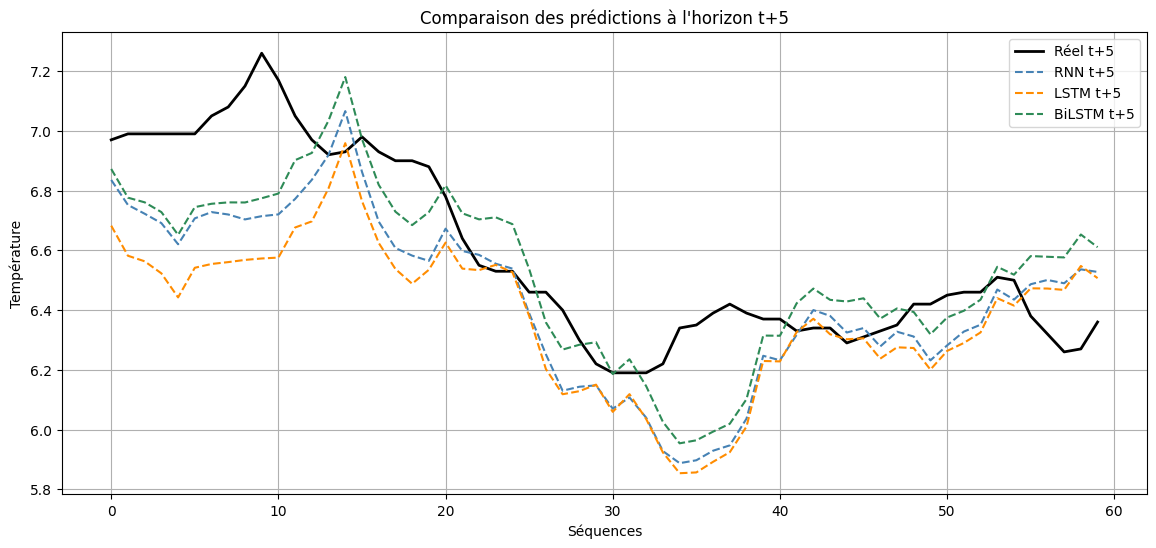

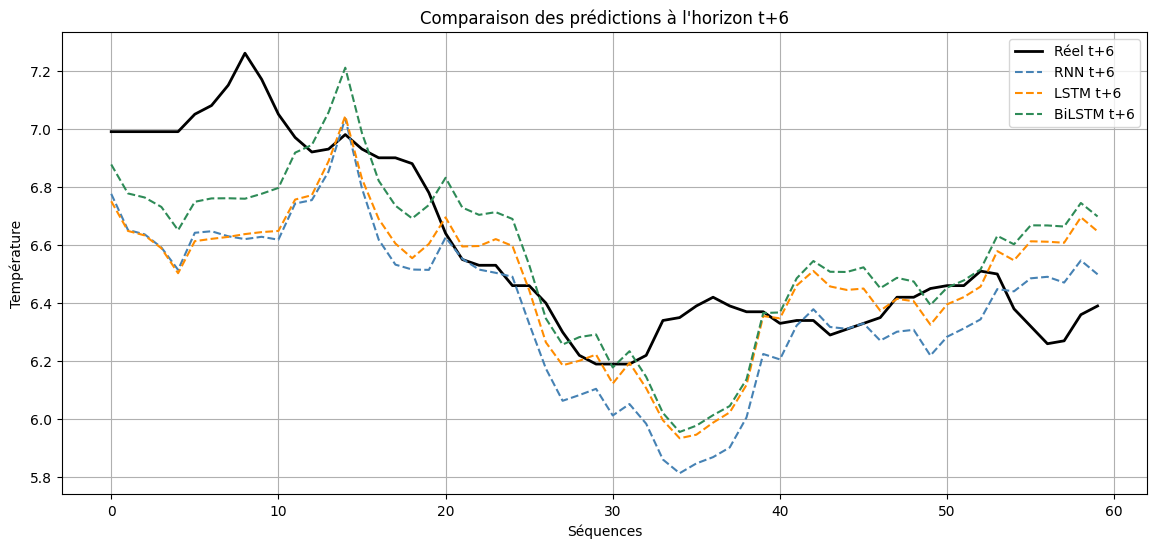

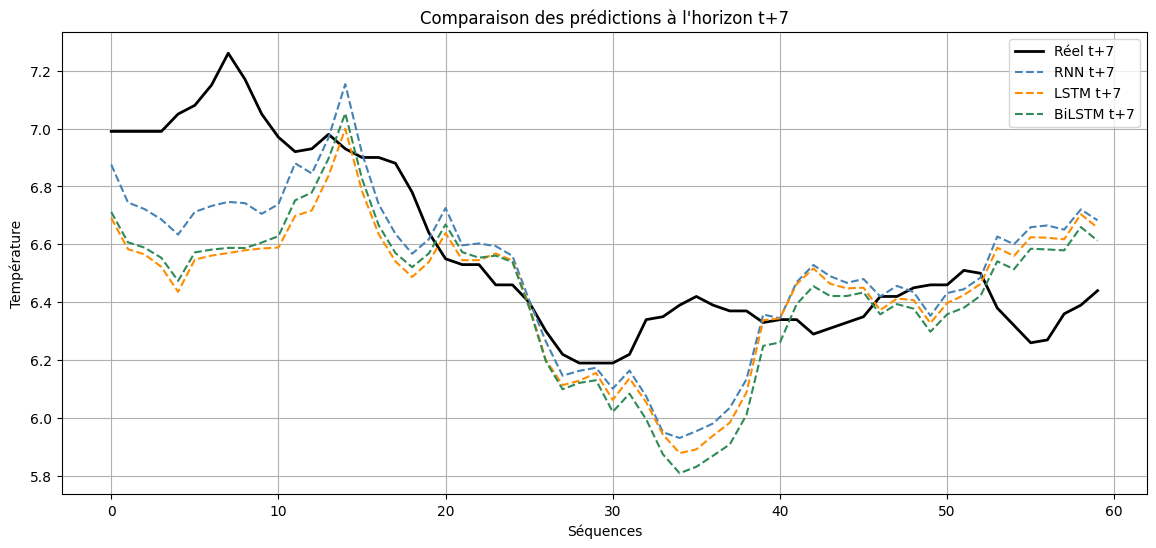

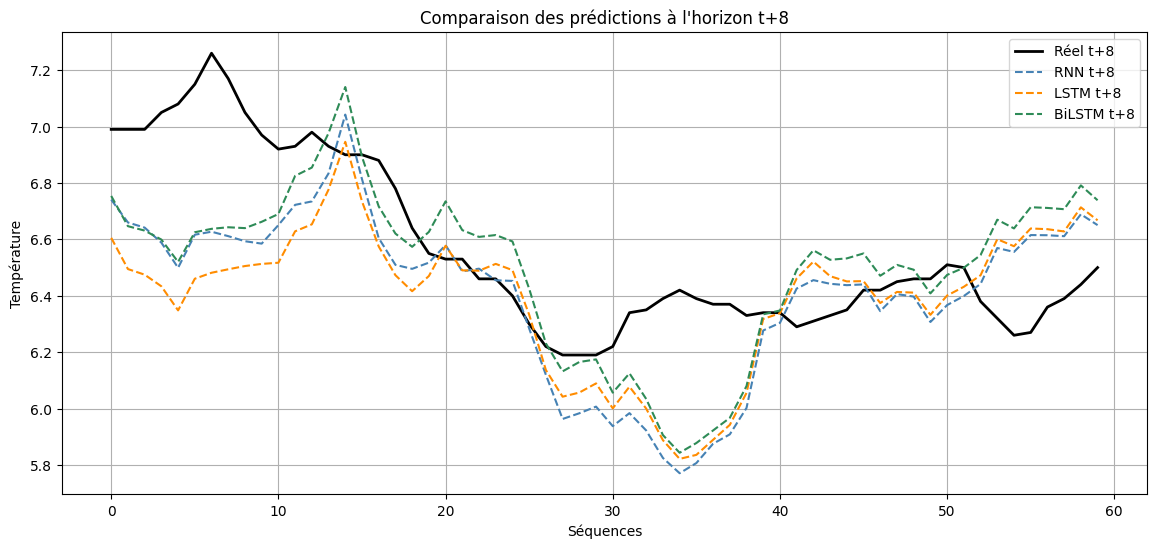

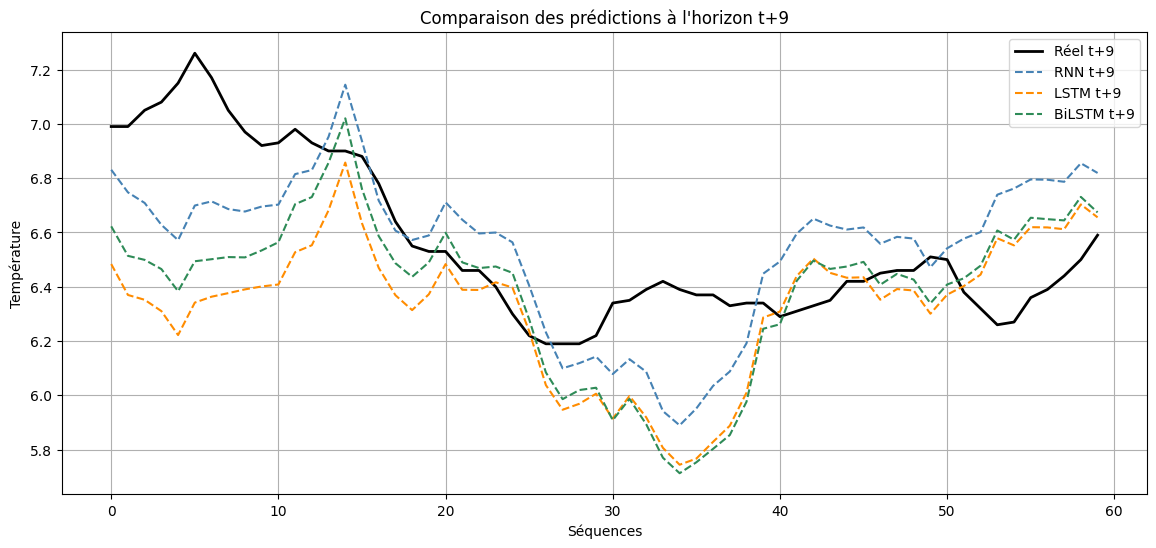

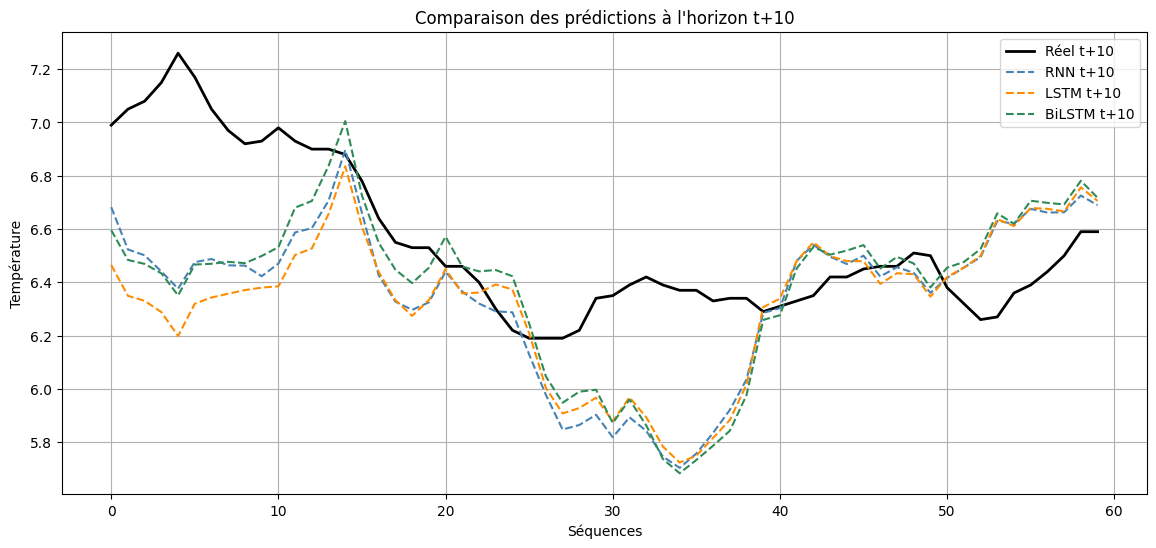

In [13]:
#Q10) Visualiser les prédictions de t+1 à t+10 pour une séquence du test

START = min(200, len(X_test) - 60)
N = 60

# Boucle sur les 10 horizons
for h in range(HORIZON):
    plt.figure(figsize=(14, 6))

    sl = slice(START, START + N)

    # valeurs real
    plt.plot(true_test[sl, h], color='black', lw=2, label=f"Réel t+{h+1}")

    # valeurs pred
    plt.plot(pred_rnn[sl, h], color='steelblue', lw=1.5, linestyle='--', label=f"RNN t+{h+1}")
    plt.plot(pred_lstm[sl, h], color='darkorange', lw=1.5, linestyle='--', label=f"LSTM t+{h+1}")
    plt.plot(pred_bilstm[sl, h], color='seagreen', lw=1.5, linestyle='--', label=f"BiLSTM t+{h+1}")

    plt.title(f"Comparaison des prédictions à l'horizon t+{h+1}")
    plt.xlabel("Séquences")
    plt.ylabel("Température")

    plt.legend()
    plt.grid(True)

    plt.show()

**Q12** : La prédiction à 10 pas est plus difficile qu’à 1 pas car plus on s’éloigne dans le futur, plus l’incertitude augmente et la relation avec les données passées devient faible. À court terme (t+1), la température change peu et reste fortement corrélée aux valeurs précédentes, ce qui facilite la prédiction. En revanche, à long terme (t+10), des facteurs imprévisibles peuvent intervenir, ce qui réduit la précision du modèle et entraîne une augmentation des erreurs.

**Q13** : Il faut revenir à l’échelle originale car les métriques doivent être interprétées dans l’unité réelle du problème, ici les degrés Celsius. Si on calcule MAE ou RMSE sur des valeurs normalisées, on obtient des nombres artificiels entre 0 et 1 qui ne reflètent pas directement l’erreur réelle en température. L’inverse scaling permet donc une évaluation correcte, compréhensible et comparable.

**Q14** :

 Un LSTM bidirectionnel est constitué de deux réseaux LSTM qui analysent la même séquence dans deux directions opposées.

 **Le premier (forward)** traite les données dans l’ordre normal, du passé vers le futur, en capturant les dépendances temporelles classiques.

 **Le second (backward)** parcourt la séquence en sens inverse, du futur vers le passé, ce qui lui permet d’exploiter des informations qui apparaissent plus tard dans la séquence.

 => *Les sorties des deux réseaux sont ensuite combinées (généralement par concaténation), ce qui fournit une représentation plus riche et plus complète de la séquence.*

**L’avantage principal** est que chaque point de la séquence est analysé avec une double vision : ce qui s’est passé avant et ce qui arrive après. Cela permet au modèle de mieux capturer les relations complexes dans les données et d’améliorer la précision des prédictions par rapport à un LSTM classique.

**En revanche**, ce type de modèle nécessite de disposer de toute la séquence à l’avance, ce qui le rend moins adapté aux prédictions en temps réel où les données futures ne sont pas encore connues.